# E_S1 — Full paired SNR sweep generation (multi-distribution, selected + other, heteroscedasticity)

Generates **selected** (14 families) and **other** (12 families) signal groups for the `mild`, `standard`, and `strong` variants over one common 227-level SNR grid, across **4 X distributions** and **4 spread patterns** (heteroscedasticity).

Within each family × variant × replicate trajectory, branch assignment and the standard-normal noise vector are fixed; only the noise scale and spread pattern change. Each combination is generated and saved independently.

Output structure: `F/output/E/E_S1/{spread_pattern}/{selected|other}/{distribution}/`

Spread patterns: `constant`, `increasing`, `decreasing`, `middle_high`

Per spread × group × distribution:
- **Selected**: 14 families × 3 variants × 227 SNR × 10 reps = 95,340 signal + 100 Null = 95,440 cases
- **Other**: 12 families × 3 variants × 227 SNR × 10 reps = 81,720 signal + 100 Null = 81,820 cases

Each case contains 500 points.

Switch for noise distribution variation is provided but disabled by default.

The notebook defaults to `full`. For a small validation run, launch it with `SNR_SWEEP_MODE=pilot`.

In [7]:
from __future__ import annotations

import hashlib
import json
import math
import os
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kwargs):
        return it

try:
    from IPython.display import display
except ImportError:
    display = print

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

## Configuration and source reuse

Function formulas and the three parameter variants are loaded from `D_S1_scatterplot_generation.ipynb`. The source notebook is not executed as an experiment and is not modified.

X distribution, spread pattern, and noise distribution switches are configured here.

In [8]:
RUN_MODE = os.environ.get('SNR_SWEEP_MODE', 'full').strip().lower()
if RUN_MODE not in {'full', 'pilot'}:
    raise ValueError("SNR_SWEEP_MODE must be 'full' or 'pilot'")

OVERWRITE = os.environ.get('SNR_SWEEP_OVERWRITE', '0') == '1'
MASTER_SEED = 20260720

SELECTED_FAMILIES = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
OTHER_FAMILIES = [
    'F02', 'F04', 'F06', 'F08', 'F09', 'F10',
    'F11', 'F12', 'F14', 'F16', 'F17', 'F20',
]
FAMILY_GROUPS = {'selected': SELECTED_FAMILIES, 'other': OTHER_FAMILIES}
VARIANT_LEVELS = ['mild', 'standard', 'strong']

# ── X distribution settings ──
X_DISTRIBUTIONS = ['even', 'left_dense', 'right_dense', 'center_dense']

# ── Spread pattern settings ──
SPREAD_PATTERNS = ['constant', 'increasing', 'decreasing', 'middle_high']
ENABLE_SPREAD_VARIATION = True
ACTIVE_SPREAD_PATTERNS = SPREAD_PATTERNS if ENABLE_SPREAD_VARIATION else ['constant']

# ── Noise distribution switch (disabled by default) ──
ENABLE_NOISE_VARIATION = False

def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D' / 'D_S1_scatterplot_generation.ipynb').exists():
            return root
    raise FileNotFoundError('Could not locate D/D_S1_scatterplot_generation.ipynb')

REPO_ROOT = locate_repo_root()
SOURCE_S1 = REPO_ROOT / 'D' / 'D_S1_scatterplot_generation.ipynb'
E_S1_OUTPUT_BASE = REPO_ROOT / 'F' / 'output' / 'E' / 'E_S1'

with SOURCE_S1.open('r', encoding='utf-8') as handle:
    source_nb = json.load(handle)

def source_cell(index: int) -> str:
    return ''.join(source_nb['cells'][index]['source'])

exec(compile(source_cell(3), f'{SOURCE_S1.name}:cell3', 'exec'), globals())
shape_cell = source_cell(5).split('\nshape_configs = build_shape_configs()', 1)[0]
exec(compile(shape_cell, f'{SOURCE_S1.name}:cell5', 'exec'), globals())
shape_configs_all = build_shape_configs()

exec(compile(source_cell(7), f'{SOURCE_S1.name}:cell7', 'exec'), globals())
exec(compile(source_cell(9), f'{SOURCE_S1.name}:cell9', 'exec'), globals())

group_shape_configs = {}
for _gname, _families in FAMILY_GROUPS.items():
    _configs = [
        cfg for cfg in shape_configs_all
        if cfg.family_id in _families and cfg.variant_level in VARIANT_LEVELS
    ]
    _configs.sort(key=lambda cfg, fams=_families: (
        fams.index(cfg.family_id), VARIANT_LEVELS.index(cfg.variant_level)
    ))
    assert len(_configs) == len(_families) * 3
    group_shape_configs[_gname] = _configs

print(f'RUN_MODE: {RUN_MODE}')
print(f'Source S1: {SOURCE_S1}')
print(f'Output base: {E_S1_OUTPUT_BASE}')
print(f'X distributions: {X_DISTRIBUTIONS}')
print(f'Spread patterns: {ACTIVE_SPREAD_PATTERNS}')
print(f'Noise variation: {ENABLE_NOISE_VARIATION}')
for _gname, _configs in group_shape_configs.items():
    print(f'  [{_gname}] {len(_configs)} shape configs '
          f'({len(FAMILY_GROUPS[_gname])} families)')

,family_id,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,F01,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,F02,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0
2,F03,Power convex positive,"y = x^p, p > 1",exponent p,positive,nonlinear,monotonic,convex,none,0
3,F04,Power convex negative,"y = -x^p, p > 1",exponent p,negative,nonlinear,monotonic,concave,none,0
4,F05,Power concave positive,"y = x^p, 0 < p < 1",exponent p,positive,nonlinear,monotonic,concave,none,0
5,F06,Power concave negative,"y = -x^p, 0 < p < 1",exponent p,negative,nonlinear,monotonic,convex,none,0
6,F07,Saturation positive,y = 1 - exp(-kx),rate k,positive,nonlinear,monotonic,concave,saturation,0
7,F08,Saturation negative,y = -(1 - exp(-kx)),rate k,negative,nonlinear,monotonic,convex,saturation,0
8,F09,Log positive,y = log(1 + ax),scale a,positive,nonlinear,monotonic,concave,none,0
9,F10,Log negative,y = -log(1 + ax),scale a,negative,nonlinear,monotonic,convex,none,0


RUN_MODE: full
Source S1: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/D_S1_scatterplot_generation.ipynb
Output base: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/E/E_S1
X distributions: ['even', 'left_dense', 'right_dense', 'center_dense']
Spread patterns: ['constant', 'increasing', 'decreasing', 'middle_high']
Noise variation: False
  [selected] 42 shape configs (14 families)
  [other] 36 shape configs (12 families)


## Build the 227-level SNR grid

- Original S1 grid: 200 geometric values from 0.001 to 500, five high-SNR values, and infinity = 206 levels.
- Add SNR = 100.
- Add 20 values evenly spaced on the `1/SNR` axis strictly between infinity and 100.
- Merge and deduplicate = 227 levels.

In [9]:
original_snr = sorted(
    np.geomspace(0.001, 500, 200).tolist() + [750.0, 1000.0, 2000.0, 5000.0, 10000.0]
) + [math.inf]

high_inverse_snr = np.linspace(0.0, 0.01, 22)[1:-1]
added_high_snr = (1.0 / high_inverse_snr).tolist()
finite_snr = sorted(set(float(v) for v in original_snr if np.isfinite(v)) | {100.0} | set(added_high_snr))
full_snr_grid = finite_snr + [math.inf]

assert len(original_snr) == 206
assert len(added_high_snr) == 20
assert len(full_snr_grid) == 227
assert full_snr_grid[-1] == math.inf

if RUN_MODE == 'pilot':
    PILOT_FAMILIES = {'selected': ['F01', 'F23'], 'other': ['F02', 'F04']}
    group_active_configs = {}
    for _gname, _configs in group_shape_configs.items():
        _pilot_fams = PILOT_FAMILIES[_gname]
        group_active_configs[_gname] = [
            cfg for cfg in _configs if cfg.family_id in _pilot_fams
        ]
    SNR_GRID = [0.1, 1.0, 10.0, 100.0, math.inf]
    N_SIGNAL_REPLICATES = 2
    N_PER_CASE = 100
    N_NULL = 10
else:
    group_active_configs = dict(group_shape_configs)
    SNR_GRID = full_snr_grid
    N_SIGNAL_REPLICATES = 10
    N_PER_CASE = 500
    N_NULL = 100

group_counts = {}
for _gname, _configs in group_active_configs.items():
    _n_sig = len(_configs) * len(SNR_GRID) * N_SIGNAL_REPLICATES
    _n_tot = _n_sig + N_NULL
    group_counts[_gname] = {
        'configs': _configs,
        'families': [f for f in FAMILY_GROUPS[_gname]
                     if any(c.family_id == f for c in _configs)],
        'n_signal': _n_sig,
        'n_total': _n_tot,
    }

print(f'Full SNR levels: {len(full_snr_grid)}')
print(f'Active SNR levels: {len(SNR_GRID)}')
for _gname, _counts in group_counts.items():
    print(f'  [{_gname}] {_counts["n_signal"]:,} signal + {N_NULL} Null '
          f'= {_counts["n_total"]:,} cases')
_total_per_combo = sum(c['n_total'] for c in group_counts.values())
_n_combos = len(ACTIVE_SPREAD_PATTERNS) * len(X_DISTRIBUTIONS)
print(f'Per spread × distribution: {_total_per_combo:,} cases')
print(f'Total ({len(ACTIVE_SPREAD_PATTERNS)} spread × {len(X_DISTRIBUTIONS)} dist): '
      f'{_total_per_combo * _n_combos:,} cases')
print(f'Points per case: {N_PER_CASE}')

Full SNR levels: 227
Active SNR levels: 227
  [selected] 95,340 signal + 100 Null = 95,440 cases
  [other] 81,720 signal + 100 Null = 81,820 cases
Per spread × distribution: 177,260 cases
Total (4 spread × 4 dist): 2,836,160 cases
Points per case: 500


## Generation function

Defines `generate_for_distribution(x_dist, active_configs, n_total, spread_pattern)` which generates all paired SNR trajectories for one X distribution, one family group, and one spread pattern. The seed does NOT include spread_pattern, so x, y_signal, and noise_z are shared across spread patterns for controlled comparison — only the noise multiplier differs.

In [10]:
def stable_seed(*parts: Any) -> int:
    payload = '|'.join(map(str, (MASTER_SEED, *parts))).encode('utf-8')
    return int.from_bytes(hashlib.blake2b(payload, digest_size=8).digest(), 'little')

def snr_zone(snr: float) -> str:
    if math.isinf(float(snr)) or snr >= 5.0:
        return 'clear'
    if snr >= 1.0:
        return 'clear_to_fuzzy'
    if snr >= 0.4:
        return 'fuzzy_to_unrecognisable'
    return 'unrecognisable'


def generate_for_distribution(
    x_dist: str,
    active_configs: list,
    n_total: int,
    spread_pattern: str = 'constant',
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, float]:
    """Generate all paired SNR trajectory cases for one X distribution, family group, and spread pattern."""

    x_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)
    y_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)
    records: list[dict[str, Any]] = []

    row = 0
    started = time.time()
    for cfg in tqdm(active_configs, desc=f'{x_dist}'):
        labels = FAMILY_LABELS[cfg.family_id]

        for repeat in range(1, N_SIGNAL_REPLICATES + 1):
            trajectory_id = f'{cfg.family_id}_{cfg.variant_level}_r{repeat:02d}'
            x = sample_x(N_PER_CASE, x_dist,
                         np.random.default_rng(stable_seed(x_dist, trajectory_id, 'x')))
            y_signal = evaluate_signal(
                x, cfg,
                rng=np.random.default_rng(stable_seed(x_dist, trajectory_id, 'branch')))
            noise_z = np.random.default_rng(
                stable_seed(x_dist, trajectory_id, 'noise')).normal(0.0, 1.0, N_PER_CASE)
            spread = spread_multiplier(x, spread_pattern)
            sample_signal_variance = float(np.var(y_signal, ddof=0))

            for snr in SNR_GRID:
                sigma0 = sigma0_for_snr(cfg, snr)
                noise = sigma0 * spread * noise_z
                y = y_signal + noise
                sample_noise_variance = float(np.var(noise, ddof=0))
                actual_snr = (
                    math.inf if sample_noise_variance == 0.0
                    else sample_signal_variance / sample_noise_variance
                )
                case_id = f'S{row + 1:06d}'

                x_all[row] = x
                y_all[row] = y
                records.append({
                    'candidate_index': row,
                    'case_id': case_id,
                    'trajectory_id': trajectory_id,
                    'family_id': cfg.family_id,
                    'family_name': labels['family_name'],
                    'shape_config_id': cfg.shape_config_id,
                    'variant_name': cfg.variant_name,
                    'variant_level': cfg.variant_level,
                    'repeat': repeat,
                    'nominal_snr': float(snr),
                    'inverse_snr': 0.0 if math.isinf(float(snr)) else 1.0 / float(snr),
                    'actual_snr': float(actual_snr),
                    'sigma0': float(sigma0),
                    'snr_zone': snr_zone(float(snr)),
                    'n_points': N_PER_CASE,
                    'x_distribution': x_dist,
                    'spread_pattern': spread_pattern,
                    'trajectory_seed': stable_seed(x_dist, trajectory_id),
                    'is_null': False,
                    'params_json': json.dumps(cfg.params, sort_keys=True),
                })
                row += 1

    for null_repeat in range(1, N_NULL + 1):
        null_id = f'Null_r{null_repeat:03d}'
        x = sample_x(N_PER_CASE, x_dist,
                      np.random.default_rng(stable_seed(x_dist, null_id, 'x')))
        y = np.random.default_rng(
            stable_seed(x_dist, null_id, 'y')).normal(0.0, 1.0, N_PER_CASE)
        case_id = f'N{null_repeat:03d}'

        x_all[row] = x
        y_all[row] = y
        records.append({
            'candidate_index': row,
            'case_id': case_id,
            'trajectory_id': null_id,
            'family_id': 'Null',
            'family_name': 'No relationship',
            'shape_config_id': -1,
            'variant_name': 'independent_normal',
            'variant_level': 'none',
            'repeat': null_repeat,
            'nominal_snr': np.nan,
            'inverse_snr': np.nan,
            'actual_snr': np.nan,
            'sigma0': np.nan,
            'snr_zone': 'null',
            'n_points': N_PER_CASE,
            'x_distribution': x_dist,
            'spread_pattern': spread_pattern,
            'trajectory_seed': stable_seed(x_dist, null_id),
            'is_null': True,
            'params_json': '{}',
        })
        row += 1

    cases_df = pd.DataFrame(records)
    elapsed = time.time() - started
    assert row == n_total and len(cases_df) == n_total
    return cases_df, x_all, y_all, elapsed


print('Generation function defined.')

Generation function defined.


## Generate and save all spread × group × distribution

Loops over each spread pattern, family group, and X distribution, generating all cases and saving to `E_S1/{spread}/{group}/{distribution}/`.

In [11]:
for spread_pat in ACTIVE_SPREAD_PATTERNS:
    for group_name, counts in group_counts.items():
        g_configs = counts['configs']
        g_families = counts['families']
        n_total = counts['n_total']

        for x_dist in X_DISTRIBUTIONS:
            out_dir = E_S1_OUTPUT_BASE / spread_pat / group_name / x_dist
            tag = f'{spread_pat}/{group_name}/{x_dist}'
            expected_outputs = [
                out_dir / 'cases.csv',
                out_dir / 'scatter_points.npz',
                out_dir / 'generation_metadata.json',
            ]
            existing = [p for p in expected_outputs if p.exists()]
            if existing and not OVERWRITE:
                print(f'[{tag}] Skipping — output exists. '
                      'Set SNR_SWEEP_OVERWRITE=1 to replace.')
                continue

            cases_df, x_all, y_all, elapsed = generate_for_distribution(
                x_dist, g_configs, n_total, spread_pat)

            out_dir.mkdir(parents=True, exist_ok=True)
            cases_df.to_csv(out_dir / 'cases.csv', index=False)
            np.savez(out_dir / 'scatter_points.npz', x=x_all, y=y_all)

            metadata = {
                'run_mode': RUN_MODE,
                'master_seed': MASTER_SEED,
                'source_s1': str(SOURCE_S1),
                'family_group': group_name,
                'families': g_families,
                'variant_levels': VARIANT_LEVELS,
                'n_shape_configs': len(g_configs),
                'n_signal_replicates': N_SIGNAL_REPLICATES,
                'n_null': N_NULL,
                'n_points_per_case': N_PER_CASE,
                'n_snr_levels': len(SNR_GRID),
                'snr_grid': ['inf' if math.isinf(v) else float(v) for v in SNR_GRID],
                'n_signal_cases': counts['n_signal'],
                'n_total_cases': n_total,
                'paired_trajectory': True,
                'x_distribution': x_dist,
                'spread_pattern': spread_pat,
                'enable_spread_variation': ENABLE_SPREAD_VARIATION,
                'enable_noise_variation': ENABLE_NOISE_VARIATION,
                'elapsed_seconds': elapsed,
            }
            with (out_dir / 'generation_metadata.json').open('w', encoding='utf-8') as f:
                json.dump(metadata, f, indent=2, ensure_ascii=False)

            print(f'[{tag}] Saved {n_total:,} cases in {elapsed:.0f}s:')
            for p in expected_outputs:
                print(f'  {p.name}: {p.stat().st_size / 1024**2:.2f} MiB')

            del cases_df, x_all, y_all

even: 100%|██████████| 42/42 [00:01<00:00, 24.11it/s]


[constant/selected/even] Saved 95,440 cases in 2s:
  cases.csv: 24.09 MiB
  scatter_points.npz: 364.08 MiB
  generation_metadata.json: 0.01 MiB


left_dense: 100%|██████████| 42/42 [00:01<00:00, 24.94it/s]


[constant/selected/left_dense] Saved 95,440 cases in 2s:
  cases.csv: 24.65 MiB
  scatter_points.npz: 364.08 MiB
  generation_metadata.json: 0.01 MiB


right_dense: 100%|██████████| 42/42 [00:01<00:00, 24.73it/s]


...

[middle_high/other/left_dense] Saved 81,820 cases in 2s:
  cases.csv: 19.18 MiB
  scatter_points.npz: 312.12 MiB
  generation_metadata.json: 0.01 MiB


right_dense: 100%|██████████| 36/36 [00:01<00:00, 25.41it/s]


[middle_high/other/right_dense] Saved 81,820 cases in 2s:
  cases.csv: 19.26 MiB
  scatter_points.npz: 312.12 MiB
  generation_metadata.json: 0.01 MiB


center_dense: 100%|██████████| 36/36 [00:01<00:00, 25.12it/s]


[middle_high/other/center_dense] Saved 81,820 cases in 2s:
  cases.csv: 19.36 MiB
  scatter_points.npz: 312.12 MiB
  generation_metadata.json: 0.01 MiB


## Validation and output summary

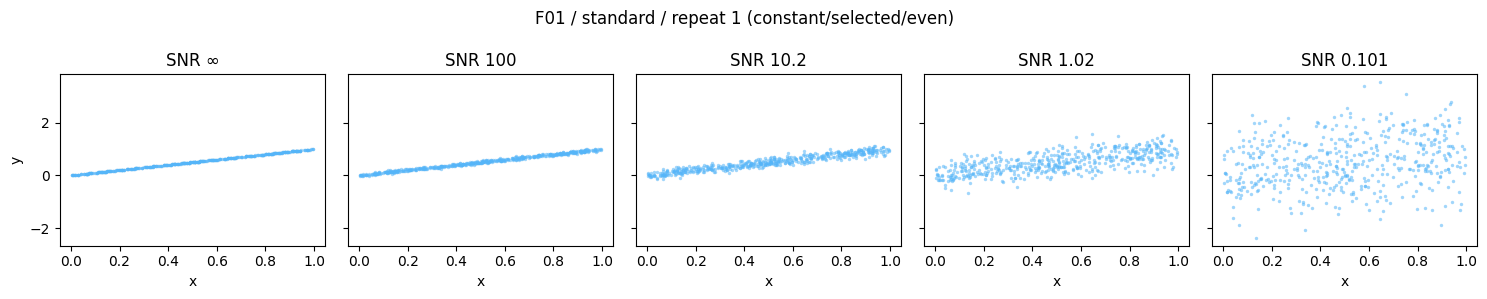


=== Output summary ===

=== constant ===
  --- selected ---
    even           : 95,440 cases, 364.1 MiB
    left_dense     : 95,440 cases, 364.1 MiB
    right_dense    : 95,440 cases, 364.1 MiB
    center_dense   : 95,440 cases, 364.1 MiB
  --- other ---
    even           : 81,820 cases, 312.1 MiB
    left_dense     : 81,820 cases, 312.1 MiB
    right_dense    : 81,820 cases, 312.1 MiB
    center_dense   : 81,820 cases, 312.1 MiB

=== increasing ===
  --- selected ---
    even           : 95,440 cases, 364.1 MiB
    left_dense     : 95,440 cases, 364.1 MiB
    right_dense    : 95,440 cases, 364.1 MiB
    center_dense   : 95,440 cases, 364.1 MiB
  --- other ---
    even           : 81,820 cases, 312.1 MiB
    left_dense     : 81,820 cases, 312.1 MiB
    right_dense    : 81,820 cases, 312.1 MiB
    center_dense   : 81,820 cases, 312.1 MiB

=== decreasing ===
  --- selected ---
    even           : 95,440 cases, 364.1 MiB
    left_dense     : 95,440 cases, 364.1 MiB
    right_dense    

In [12]:
first_spread = ACTIVE_SPREAD_PATTERNS[0]
first_group = list(group_counts.keys())[0]
first_families = group_counts[first_group]['families']
preview_dist = X_DISTRIBUTIONS[0]
preview_dir = E_S1_OUTPUT_BASE / first_spread / first_group / preview_dist
loaded_cases = pd.read_csv(preview_dir / 'cases.csv', low_memory=False)
with np.load(preview_dir / 'scatter_points.npz') as points:
    loaded_x = points['x']
    loaded_y = points['y']

assert len(loaded_cases) == loaded_x.shape[0] == loaded_y.shape[0]

preview_family = first_families[0]
preview_variant = 'standard'
preview_repeat = 1
preview = loaded_cases[
    (loaded_cases['family_id'] == preview_family)
    & (loaded_cases['variant_level'] == preview_variant)
    & (loaded_cases['repeat'] == preview_repeat)
].copy()
preview_rows = []
for target in [math.inf, 100.0, 10.0, 1.0, 0.1]:
    if math.isinf(target):
        chosen = preview[np.isinf(preview['nominal_snr'])].iloc[0]
    else:
        finite = preview[np.isfinite(preview['nominal_snr'])].copy()
        chosen = finite.iloc[np.abs(np.log(finite['nominal_snr'] / target)).argmin()]
    preview_rows.append(chosen)

fig, axes = plt.subplots(1, len(preview_rows), figsize=(15, 3), sharex=True, sharey=True)
for ax, case in zip(axes, preview_rows):
    idx = int(case['candidate_index'])
    ax.scatter(loaded_x[idx], loaded_y[idx], s=6, alpha=0.55, color='#55B5F8', linewidths=0)
    title_snr = '∞' if np.isinf(case['nominal_snr']) else f"{case['nominal_snr']:.3g}"
    ax.set_title(f'SNR {title_snr}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
fig.suptitle(f'{preview_family} / {preview_variant} / repeat {preview_repeat} '
             f'({first_spread}/{first_group}/{preview_dist})')
fig.tight_layout()
plt.show()

print('\n=== Output summary ===')
for spread_pat in ACTIVE_SPREAD_PATTERNS:
    print(f'\n=== {spread_pat} ===')
    for group_name in group_counts:
        print(f'  --- {group_name} ---')
        for dist in X_DISTRIBUTIONS:
            dist_dir = E_S1_OUTPUT_BASE / spread_pat / group_name / dist
            if (dist_dir / 'cases.csv').exists():
                n = len(pd.read_csv(dist_dir / 'cases.csv', usecols=['case_id']))
                size = (dist_dir / 'scatter_points.npz').stat().st_size / 1024**2
                print(f'    {dist:15s}: {n:,} cases, {size:.1f} MiB')
            else:
                print(f'    {dist:15s}: not generated')

del loaded_cases, loaded_x, loaded_y
print('\nValidation passed.')